<a href="https://colab.research.google.com/github/yongjin0213/dmz-surveillance-ai/blob/main/YOLO_pose_tracker.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
!pip install ultralytics --quiet

In [29]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [30]:
BASE_DIR = "/content/drive/MyDrive/summer '26/DMZ"
CLIPS_DIR = f"{BASE_DIR}/clips"
LABELS_CSV = f"{BASE_DIR}/labels.csv"
KEYPOINT_DIR = f"{BASE_DIR}/keypoints"

In [31]:
import os
print(os.listdir(CLIPS_DIR))

['salute_1.MOV', 'salute_5.MOV', 'salute_6.MOV', 'salute_7.MOV', 'salute_2.MOV', 'salute_0.MOV', 'salute_3.MOV', 'salute_4.MOV', 'salute_11.MOV', 'salute_10.MOV', 'salute_8.MOV', 'salute_9.MOV', 'marching_1.MOV', 'marching_3.MOV', 'marching_0.MOV', 'marching_4.MOV', 'marching_2.MOV', 'marching_5.MOV', 'salute_16.MOV', 'salute_14.MOV', 'salute_13.MOV', 'salute_15.MOV', 'salute_12.MOV', 'salute_23.MOV', 'salute_17.MOV', 'salute_20.MOV', 'salute_22.MOV', 'salute_19.MOV', 'salute_24.MOV', 'marching_6.MOV', 'marching_10.MOV', 'maching_7.MOV', 'salute_21.MOV', 'salute_18.MOV', 'marching_8.MOV', 'marching_13.MOV', 'marching_11.MOV', 'marching_9.MOV', 'marching_14.MOV', 'marching_15.MOV', 'marching_12.MOV']


In [32]:
os.makedirs(KEYPOINT_DIR, exist_ok=True)

In [33]:
from ultralytics import YOLO
import numpy as np

def extract_keypoints_from_clip(video_path, seq_len=30):
  results = pose_model.track(source=video_path, persist=True, stream=True)
  frames_keypoints = []

  for r in results:
    if r.keypoints is not None and len(r.keypoints.xy)>0:
      kpts = r.keypoints.xy[0].cpu().numpy()
      frames_keypoints.append(kpts)
  if len(frames_keypoints) == 0:
    print(f"WARNING: no person detected in {video_path}")
    return None
  frames_keypoints = np.array(frames_keypoints)
  if len(frames_keypoints) < seq_len:
    pad = np.zeros((seq_len - len(frames_keypoints), 17, 2))
    frames_keypoints = np.concatenate((frames_keypoints, pad), axis=0)
  else:
    frames_keypoints = frames_keypoints[:seq_len]
  return frames_keypoints

def normalize_keypoints(kpts):
    hip_center = (kpts[:, 11, :] + kpts[:, 12, :]) / 2
    kpts_centered = kpts - hip_center[:, None, :]
    torso_len = np.linalg.norm(kpts[:, 5, :] - kpts[:, 11, :], axis=-1, keepdims=True)
    torso_len = np.clip(torso_len, 1e-3, None)
    return kpts_centered / torso_len[:, :, None]


In [35]:
import pandas as pd
from ultralytics import YOLO
import numpy as np

pose_model = YOLO("yolo26n-pose.pt")

df = pd.read_csv(LABELS_CSV)

for _, row in df.iterrows():
    clip_path = f"{CLIPS_DIR}/{row['filename']}.MOV"
    kpts = extract_keypoints_from_clip(clip_path)
    if kpts is not None:
        kpts_norm = normalize_keypoints(kpts)
        np.save(f"{KEYPOINT_DIR}/{row['filename']}.npy", kpts_norm)
        print(f"Saved {row['filename']} → {kpts_norm.shape}")


video 1/1 (frame 1/131) /content/drive/MyDrive/summer '26/DMZ/clips/salute_0.MOV: 640x384 1 person, 10.1ms
video 1/1 (frame 2/131) /content/drive/MyDrive/summer '26/DMZ/clips/salute_0.MOV: 640x384 1 person, 11.1ms
video 1/1 (frame 3/131) /content/drive/MyDrive/summer '26/DMZ/clips/salute_0.MOV: 640x384 1 person, 11.4ms
video 1/1 (frame 4/131) /content/drive/MyDrive/summer '26/DMZ/clips/salute_0.MOV: 640x384 1 person, 10.6ms
video 1/1 (frame 5/131) /content/drive/MyDrive/summer '26/DMZ/clips/salute_0.MOV: 640x384 1 person, 11.2ms
video 1/1 (frame 6/131) /content/drive/MyDrive/summer '26/DMZ/clips/salute_0.MOV: 640x384 1 person, 10.7ms
video 1/1 (frame 7/131) /content/drive/MyDrive/summer '26/DMZ/clips/salute_0.MOV: 640x384 1 person, 10.8ms
video 1/1 (frame 8/131) /content/drive/MyDrive/summer '26/DMZ/clips/salute_0.MOV: 640x384 1 person, 10.4ms
video 1/1 (frame 9/131) /content/drive/MyDrive/summer '26/DMZ/clips/salute_0.MOV: 640x384 1 person, 10.4ms
video 1/1 (frame 10/131) /content/dr

In [36]:
import os
print(os.listdir(KEYPOINT_DIR))

['salute_0.npy', 'salute_1.npy', 'salute_2.npy', 'salute_3.npy', 'salute_4.npy', 'salute_5.npy', 'salute_6.npy', 'salute_7.npy', 'salute_8.npy', 'salute_9.npy', 'salute_10.npy', 'salute_11.npy', 'salute_12.npy', 'marching_0.npy', 'marching_1.npy', 'marching_2.npy', 'marching_3.npy', 'marching_4.npy', 'marching_5.npy', 'salute_13.npy', 'salute_14.npy', 'salute_15.npy', 'salute_16.npy', 'salute_17.npy', 'salute_18.npy', 'salute_19.npy', 'salute_20.npy', 'salute_21.npy', 'salute_22.npy', 'salute_23.npy', 'salute_24.npy', 'marching_6.npy', 'marching_7.npy', 'marching_8.npy', 'marching_9.npy', 'marching_10.npy', 'marching_11.npy', 'marching_12.npy', 'marching_13.npy', 'marching_14.npy', 'marching_15.npy']


In [37]:
import torch
from torch.utils.data import Dataset
import numpy as np
import pandas as pd

class ActionDataset(Dataset):
  def __init__(self, csv_path, keypoints_dir):
    self.df = pd.read_csv(csv_path, encoding='utf-8-sig')
    self.df.columns = self.df.columns.str.strip()
    self.keypoints_dir = keypoints_dir
    self.classes = sorted(self.df["action"].unique())
    self.class_to_idx = {c: i for i, c in enumerate(self.classes)}

  def __len__(self):
    return len(self.df)

  def __getitem__(self, idx):
    row = self.df.iloc[idx]
    kpts = np.load(f"{self.keypoints_dir}/{row['filename']}.npy")
    kpts_flat = kpts.reshape(kpts.shape[0], -1)
    label = self.class_to_idx[row["action"]]
    return torch.tensor(kpts_flat, dtype=torch.float32), torch.tensor(label, dtype=torch.long)


In [38]:
dataset = ActionDataset(LABELS_CSV, KEYPOINT_DIR)
print("Classes found: ", dataset.classes)
print("Total clips: ", len(dataset))

Classes found:  ['marching', 'saluting']
Total clips:  41


In [39]:
import torch.nn as nn

class ActionClassifier(nn.Module):
  def __init__(self, num_joints=17, hidden_dim=64, num_classes=5, num_layers=1):
    super().__init__()
    input_dim = num_joints*2
    self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
    self.dropout = nn.Dropout(0.3)
    self.fc = nn.Linear(hidden_dim, num_classes)

  def forward(self, x):
    _, (h_n, _) = self.lstm(x)
    return self.fc(self.dropout(h_n[-1]))

In [41]:
import torch.nn as nn

class MLPClassifier(nn.Module):
  def __init__(self, input_dim, hidden_dim=128, num_classes=5):
    super().__init__()
    self.flatten = nn.Flatten() # Flatten the sequence and features
    self.fc1 = nn.Linear(input_dim, hidden_dim)
    self.relu = nn.ReLU()
    self.dropout = nn.Dropout(0.3)
    self.fc2 = nn.Linear(hidden_dim, num_classes)

  def forward(self, x):
    # x shape is (batch_size, seq_len, num_joints*2)
    # For MLP, we want to flatten the seq_len and features dimensions
    # to (batch_size, seq_len * num_joints * 2)
    x = self.flatten(x) # Flattens all dimensions except batch_size
    x = self.fc1(x)
    x = self.relu(x)
    x = self.dropout(x)
    x = self.fc2(x)
    return x

In [42]:
from torch.utils.data import DataLoader, random_split

train_size = max(1, int(0.8*len(dataset)))
val_size = len(dataset) - train_size
train_ds, val_ds = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=4, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=4, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ActionClassifier(num_classes=len(dataset.classes)).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = torch.nn.CrossEntropyLoss()

best_val_acc = 0.0
MODEL_SAVE_PATH = f"{BASE_DIR}/best_action_classifier.pt"

for epoch in range(50):
  model.train()
  train_loss = 0.0
  for x, y in train_loader:
    x, y = x.to(device), y.to(device)
    optimizer.zero_grad()
    loss = criterion(model(x), y)
    loss.backward()
    optimizer.step()
    train_loss += loss.item()

  model.eval()
  correct, total = 0, 0

  with torch.no_grad():
    for x, y in val_loader:
      x, y = x.to(device), y.to(device)
      preds = model(x).argmax(dim=1)
      correct += (preds==y).sum().item()
      total += y.size(0)
  val_acc = correct / total if total > 0 else 0.0
  print(f"Epoch {epoch+1}/50 | Train Loss: {train_loss/len(train_loader):.4f} | Val Acc: {val_acc:.4f}")
  if val_acc >= best_val_acc:
      best_val_acc = val_acc
      torch.save(model.state_dict(), MODEL_SAVE_PATH)

print(f"Best val accuracy: {best_val_acc:.4f}")
print(f"Model saved to: {MODEL_SAVE_PATH}")


Epoch 1/50 | Train Loss: 0.6644 | Val Acc: 0.7778
Epoch 2/50 | Train Loss: 0.6545 | Val Acc: 0.7778
Epoch 3/50 | Train Loss: 0.6534 | Val Acc: 0.7778
Epoch 4/50 | Train Loss: 0.6340 | Val Acc: 0.6667
Epoch 5/50 | Train Loss: 0.6304 | Val Acc: 0.6667
Epoch 6/50 | Train Loss: 0.6025 | Val Acc: 0.6667
Epoch 7/50 | Train Loss: 0.5850 | Val Acc: 0.4444
Epoch 8/50 | Train Loss: 0.5776 | Val Acc: 0.4444
Epoch 9/50 | Train Loss: 0.5098 | Val Acc: 0.4444
Epoch 10/50 | Train Loss: 0.5503 | Val Acc: 0.5556
Epoch 11/50 | Train Loss: 0.5242 | Val Acc: 0.4444
Epoch 12/50 | Train Loss: 0.5151 | Val Acc: 0.5556
Epoch 13/50 | Train Loss: 0.4625 | Val Acc: 0.5556
Epoch 14/50 | Train Loss: 0.4458 | Val Acc: 0.5556
Epoch 15/50 | Train Loss: 0.5093 | Val Acc: 0.5556
Epoch 16/50 | Train Loss: 0.4126 | Val Acc: 0.5556
Epoch 17/50 | Train Loss: 0.3673 | Val Acc: 0.5556
Epoch 18/50 | Train Loss: 0.2952 | Val Acc: 0.5556
Epoch 19/50 | Train Loss: 0.3803 | Val Acc: 0.5556
Epoch 20/50 | Train Loss: 0.3003 | Val A

In [44]:
import torch
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

train_loader = DataLoader(train_ds, batch_size=2, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=2, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ActionClassifier(num_classes=len(dataset.classes)).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = torch.nn.CrossEntropyLoss()

MODEL_SAVE_PATH = f"{BASE_DIR}/best_action_classifier.pt"
best_val_acc = 0.0

# track history for plotting
train_losses = []
val_accs = []

for epoch in range(50):
    model.train()
    train_loss = 0.0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)

    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            preds = model(x).argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    val_acc = correct / total if total > 0 else 0.0

    train_losses.append(avg_train_loss)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/50 | Train Loss: {avg_train_loss:.4f} | Val Acc: {val_acc:.4f}")
    if val_acc >= best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), MODEL_SAVE_PATH)

print(f"Best val accuracy: {best_val_acc:.4f}")

Epoch 1/50 | Train Loss: 0.7308 | Val Acc: 0.4444
Epoch 2/50 | Train Loss: 0.6747 | Val Acc: 0.7778
Epoch 3/50 | Train Loss: 0.6497 | Val Acc: 0.6667
Epoch 4/50 | Train Loss: 0.6186 | Val Acc: 0.5556
Epoch 5/50 | Train Loss: 0.5976 | Val Acc: 0.4444
Epoch 6/50 | Train Loss: 0.5815 | Val Acc: 0.4444
Epoch 7/50 | Train Loss: 0.5638 | Val Acc: 0.5556
Epoch 8/50 | Train Loss: 0.5369 | Val Acc: 0.4444
Epoch 9/50 | Train Loss: 0.5345 | Val Acc: 0.4444
Epoch 10/50 | Train Loss: 0.5073 | Val Acc: 0.4444
Epoch 11/50 | Train Loss: 0.5116 | Val Acc: 0.4444
Epoch 12/50 | Train Loss: 0.4748 | Val Acc: 0.5556
Epoch 13/50 | Train Loss: 0.4688 | Val Acc: 0.5556
Epoch 14/50 | Train Loss: 0.4758 | Val Acc: 0.5556
Epoch 15/50 | Train Loss: 0.4234 | Val Acc: 0.5556
Epoch 16/50 | Train Loss: 0.4809 | Val Acc: 0.5556
Epoch 17/50 | Train Loss: 0.4367 | Val Acc: 0.4444
Epoch 18/50 | Train Loss: 0.3421 | Val Acc: 0.5556
Epoch 19/50 | Train Loss: 0.4222 | Val Acc: 0.5556
Epoch 20/50 | Train Loss: 0.4706 | Val A

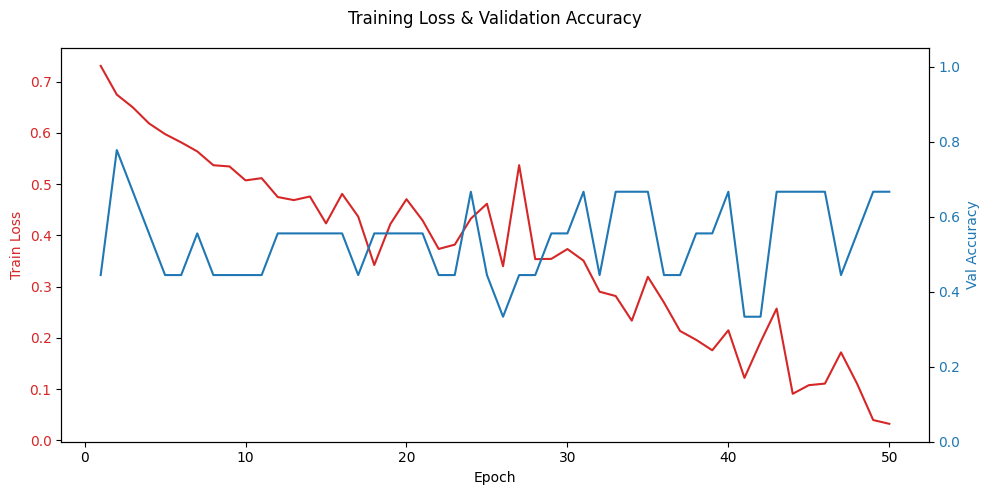

In [45]:
import matplotlib.pyplot as plt
fig, ax1 = plt.subplots(figsize=(10, 5))

epochs = range(1, len(train_losses) + 1)

color1 = "tab:red"
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Train Loss", color=color1)
ax1.plot(epochs, train_losses, color=color1, label="Train Loss")
ax1.tick_params(axis="y", labelcolor=color1)

ax2 = ax1.twinx()
color2 = "tab:blue"
ax2.set_ylabel("Val Accuracy", color=color2)
ax2.plot(epochs, val_accs, color=color2, label="Val Accuracy")
ax2.tick_params(axis="y", labelcolor=color2)
ax2.set_ylim(0, 1.05)

fig.suptitle("Training Loss & Validation Accuracy")
fig.tight_layout()
plt.show()

### MLP Model Training and Evaluation

Now, let's train and evaluate the MLP model, and then compare its performance using the F1 score.

In [46]:
from torch.utils.data import DataLoader, random_split, Dataset
from sklearn.metrics import f1_score
import torch.nn as nn
import torch
import numpy as np
import pandas as pd

# Define global path variables required by ActionDataset
# Assuming these are constant throughout the notebook
BASE_DIR = "/content/drive/MyDrive/summer '26/DMZ"
LABELS_CSV = f"{BASE_DIR}/labels.csv"
KEYPOINT_DIR = f"{BASE_DIR}/keypoints"

# Re-define ActionDataset class locally for robustness
class ActionDataset(Dataset):
  def __init__(self, csv_path, keypoints_dir):
    self.df = pd.read_csv(csv_path, encoding='utf-8-sig')
    self.df.columns = self.df.columns.str.strip()
    self.keypoints_dir = keypoints_dir
    self.classes = sorted(self.df["action"].unique())
    self.class_to_idx = {c: i for i, c in enumerate(self.classes)}

  def __len__(self):
    return len(self.df)

  def __getitem__(self, idx):
    row = self.df.iloc[idx]
    kpts = np.load(f"{self.keypoints_dir}/{row['filename']}.npy")
    kpts_flat = kpts.reshape(kpts.shape[0], -1)
    label = self.class_to_idx[row["action"]]
    return torch.tensor(kpts_flat, dtype=torch.float32), torch.tensor(label, dtype=torch.long)

# Re-define MLPClassifier class locally for robustness
class MLPClassifier(nn.Module):
  def __init__(self, input_dim, hidden_dim=128, num_classes=5):
    super().__init__()
    self.flatten = nn.Flatten() # Flatten the sequence and features
    self.fc1 = nn.Linear(input_dim, hidden_dim)
    self.relu = nn.ReLU()
    self.dropout = nn.Dropout(0.3)
    self.fc2 = nn.Linear(hidden_dim, num_classes)

  def forward(self, x):
    x = self.flatten(x) # Flattens all dimensions except batch_size
    x = self.fc1(x)
    x = self.relu(x)
    x = self.dropout(x)
    x = self.fc2(x)
    return x

# Re-initialize dataset to ensure it's defined
dataset = ActionDataset(LABELS_CSV, KEYPOINT_DIR)

# Re-initialize dataset and loaders to ensure consistent splits for comparison
train_size = max(1, int(0.8*len(dataset)))
val_size = len(dataset) - train_size
train_ds, val_ds = random_split(dataset, [train_size, val_size])

train_loader_mlp = DataLoader(train_ds, batch_size=4, shuffle=True)
val_loader_mlp = DataLoader(val_ds, batch_size=4, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Calculate input dimension for MLP: seq_len * (num_joints * 2)
sample_kpts, _ = dataset[0]
mlp_input_dim = sample_kpts.shape[0] * sample_kpts.shape[1] # seq_len * (num_joints * 2)

mlp_model = MLPClassifier(input_dim=mlp_input_dim, num_classes=len(dataset.classes)).to(device)
mlp_optimizer = torch.optim.Adam(mlp_model.parameters(), lr=1e-3)
mlp_criterion = torch.nn.CrossEntropyLoss()

best_val_f1_mlp = 0.0
MLP_MODEL_SAVE_PATH = f"{BASE_DIR}/best_mlp_action_classifier.pt"

print("\n--- Training MLP Model ---")
for epoch in range(50):
  mlp_model.train()
  train_loss_mlp = 0.0
  for x, y in train_loader_mlp:
    x, y = x.to(device), y.to(device)
    mlp_optimizer.zero_grad()
    loss = mlp_criterion(mlp_model(x), y)
    loss.backward()
    mlp_optimizer.step()
    train_loss_mlp += loss.item()

  mlp_model.eval()
  all_preds_mlp = []
  all_labels_mlp = []

  with torch.no_grad():
    for x, y in val_loader_mlp:
      x, y = x.to(device), y.to(device)
      preds = mlp_model(x).argmax(dim=1)
      all_preds_mlp.extend(preds.cpu().numpy())
      all_labels_mlp.extend(y.cpu().numpy())

  val_f1_mlp = f1_score(all_labels_mlp, all_preds_mlp, average='weighted')

  print(f"Epoch {epoch+1}/50 | Train Loss (MLP): {train_loss_mlp/len(train_loader_mlp):.4f} | Val F1 (MLP): {val_f1_mlp:.4f}")
  if val_f1_mlp >= best_val_f1_mlp:
      best_val_f1_mlp = val_f1_mlp
      torch.save(mlp_model.state_dict(), MLP_MODEL_SAVE_PATH)

print(f"\nBest Val F1 (MLP): {best_val_f1_mlp:.4f}")
print(f"MLP Model saved to: {MLP_MODEL_SAVE_PATH}")


--- Training MLP Model ---
Epoch 1/50 | Train Loss (MLP): 0.6494 | Val F1 (MLP): 0.0808
Epoch 2/50 | Train Loss (MLP): 0.5797 | Val F1 (MLP): 0.0808
Epoch 3/50 | Train Loss (MLP): 0.5634 | Val F1 (MLP): 0.0808
Epoch 4/50 | Train Loss (MLP): 0.4745 | Val F1 (MLP): 0.0808
Epoch 5/50 | Train Loss (MLP): 0.4799 | Val F1 (MLP): 0.2833
Epoch 6/50 | Train Loss (MLP): 0.4280 | Val F1 (MLP): 0.2833
Epoch 7/50 | Train Loss (MLP): 0.5058 | Val F1 (MLP): 0.2833
Epoch 8/50 | Train Loss (MLP): 0.4378 | Val F1 (MLP): 0.0808
Epoch 9/50 | Train Loss (MLP): 0.3865 | Val F1 (MLP): 0.2833
Epoch 10/50 | Train Loss (MLP): 0.3100 | Val F1 (MLP): 0.2833
Epoch 11/50 | Train Loss (MLP): 0.3466 | Val F1 (MLP): 0.2833
Epoch 12/50 | Train Loss (MLP): 0.3162 | Val F1 (MLP): 0.2833
Epoch 13/50 | Train Loss (MLP): 0.2982 | Val F1 (MLP): 0.2833
Epoch 14/50 | Train Loss (MLP): 0.3134 | Val F1 (MLP): 0.2833
Epoch 15/50 | Train Loss (MLP): 0.3032 | Val F1 (MLP): 0.2833
Epoch 16/50 | Train Loss (MLP): 0.2996 | Val F1 (ML

### F1 Score Comparison

Now let's load the best LSTM model and evaluate its F1 score on the validation set for a direct comparison with the MLP.

In [47]:
from sklearn.metrics import f1_score
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split, Dataset
import numpy as np
import pandas as pd

# Define global path variables required by ActionDataset and model paths
# Assuming these are constant throughout the notebook
BASE_DIR = "/content/drive/MyDrive/summer '26/DMZ"
LABELS_CSV = f"{BASE_DIR}/labels.csv"
KEYPOINT_DIR = f"{BASE_DIR}/keypoints"
MODEL_SAVE_PATH = f"{BASE_DIR}/best_action_classifier.pt" # LSTM model path

# Re-define ActionDataset class locally for robustness (needed for dataset creation)
class ActionDataset(Dataset):
  def __init__(self, csv_path, keypoints_dir):
    self.df = pd.read_csv(csv_path, encoding='utf-8-sig')
    self.df.columns = self.df.columns.str.strip()
    self.keypoints_dir = keypoints_dir
    self.classes = sorted(self.df["action"].unique())
    self.class_to_idx = {c: i for i, c in enumerate(self.classes)}

  def __len__(self):
    return len(self.df)

  def __getitem__(self, idx):
    row = self.df.iloc[idx]
    kpts = np.load(f"{self.keypoints_dir}/{row['filename']}.npy")
    kpts_flat = kpts.reshape(kpts.shape[0], -1)
    label = self.class_to_idx[row["action"]]
    return torch.tensor(kpts_flat, dtype=torch.float32), torch.tensor(label, dtype=torch.long)

# Re-define ActionClassifier class locally for robustness
class ActionClassifier(nn.Module):
  def __init__(self, num_joints=17, hidden_dim=64, num_classes=5, num_layers=1):
    super().__init__()
    input_dim = num_joints*2
    self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
    self.dropout = nn.Dropout(0.3)
    self.fc = nn.Linear(hidden_dim, num_classes)

  def forward(self, x):
    _, (h_n, _) = self.lstm(x)
    return self.fc(self.dropout(h_n[-1]))

# Re-initialize dataset and loaders to ensure it's defined and consistent splits for comparison
dataset = ActionDataset(LABELS_CSV, KEYPOINT_DIR)
train_size = max(1, int(0.8*len(dataset))) # Ensure train_size is at least 1 for split
val_size = len(dataset) - train_size
train_ds, val_ds = random_split(dataset, [train_size, val_size])
val_loader_mlp = DataLoader(val_ds, batch_size=4, shuffle=False) # Use the same val_loader_mlp as in the MLP cell for consistency

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the best LSTM model
lstm_model = ActionClassifier(num_classes=len(dataset.classes)).to(device)
lstm_model.load_state_dict(torch.load(MODEL_SAVE_PATH))
lstm_model.eval()

all_preds_lstm = []
all_labels_lstm = []

# Use the same validation loader as for MLP evaluation
with torch.no_grad():
    for x, y in val_loader_mlp:
        x, y = x.to(device), y.to(device)
        preds = lstm_model(x).argmax(dim=1)
        all_preds_lstm.extend(preds.cpu().numpy())
        all_labels_lstm.extend(y.cpu().numpy())

val_f1_lstm = f1_score(all_labels_lstm, all_preds_lstm, average='weighted')

print(f"LSTM Model F1 Score on Validation Set: {val_f1_lstm:.4f}")
# best_val_f1_mlp is expected to be defined from the previous cell's execution.
# This cell assumes cell ff1e484d has been run successfully to define best_val_f1_mlp.
print(f"MLP Model F1 Score on Validation Set: {best_val_f1_mlp:.4f}")

if val_f1_lstm > best_val_f1_mlp:
    print("\nThe LSTM model performed better based on F1 score.")
elif best_val_f1_mlp > val_f1_lstm:
    print("\nThe MLP model performed better based on F1 score.")
else:
    print("\nBoth models performed similarly based on F1 score.")

print("\nRegarding more clips: Yes, having more diverse clips would generally help both models learn more robust features and improve performance, especially for more complex actions or variations within actions.")

LSTM Model F1 Score on Validation Set: 0.5333
MLP Model F1 Score on Validation Set: 0.4877

The LSTM model performed better based on F1 score.

Regarding more clips: Yes, having more diverse clips would generally help both models learn more robust features and improve performance, especially for more complex actions or variations within actions.
